In [1]:
pip install pandas networkx python-louvain matplotlib scipy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Subway-only graph created with 106 nodes and 113 edges.


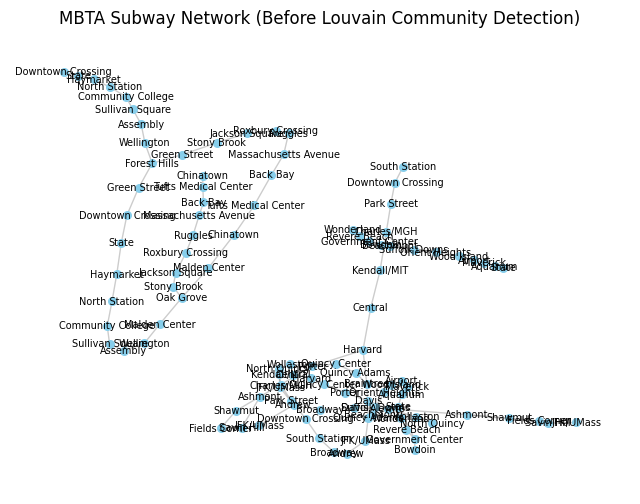

✅ Louvain community detection complete.
🧩 Modularity score: 0.8111
🗂️ Detected 11 communities.


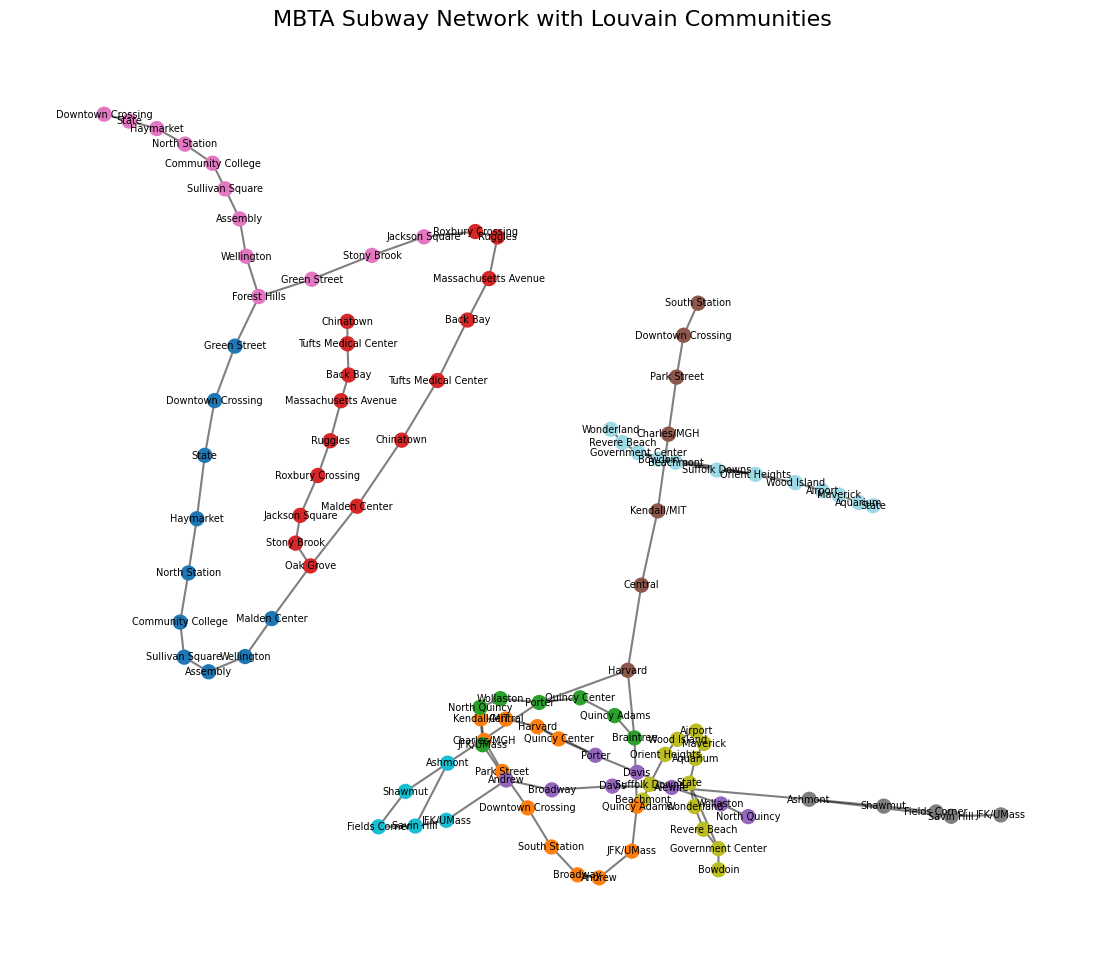

In [1]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
import zipfile

# === Step 1: Load GTFS data from ZIP file ===
zip_path = r"C:\Users\musta\Desktop\BU\pythonProject4\MBTA_GTFS (1).zip"

with zipfile.ZipFile(zip_path) as z:
    # Load required GTFS files
    with z.open("stops.txt") as stops_file, \
         z.open("stop_times.txt") as stop_times_file, \
         z.open("routes.txt") as routes_file, \
         z.open("trips.txt") as trips_file:
        
        stops_df = pd.read_csv(stops_file, dtype=str)
        stop_times_df = pd.read_csv(stop_times_file, dtype=str)
        routes_df = pd.read_csv(routes_file, dtype=str)
        trips_df = pd.read_csv(trips_file, dtype=str)

    # === Step 2: Filter only subway trips (route_type == 1) ===
    subway_routes = routes_df[routes_df["route_type"] == "1"]["route_id"]
    subway_trips = trips_df[trips_df["route_id"].isin(subway_routes)]["trip_id"]
    stop_times_df = stop_times_df[stop_times_df["trip_id"].isin(subway_trips)]

# === Step 3: Build edges from consecutive stops in each trip ===
edge_weights = defaultdict(int)

for trip_id, group in stop_times_df.groupby("trip_id"):
    group = group.sort_values("stop_sequence")
    stop_ids = group["stop_id"].tolist()

    for i in range(len(stop_ids) - 1):
        edge = tuple(sorted((stop_ids[i], stop_ids[i + 1])))
        edge_weights[edge] += 1

# === Step 4: Create the graph ===
G = nx.Graph()

# Add edges to the graph with weight (frequency of appearance)
for (stop1, stop2), weight in edge_weights.items():
    G.add_edge(stop1, stop2, weight=weight)

print(f"✅ Subway-only graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# === Step 5: Visualization before applying Louvain ===
# Visualization before applying Louvain
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # consistent layout

# Draw the graph without any community-based coloring
nx.draw_networkx_nodes(G, pos, node_size=30, node_color='skyblue')
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Add stop names for better interpretation
stop_names_dict = dict(zip(stops_df['stop_id'], stops_df['stop_name']))
labels = {node: stop_names_dict.get(node, node) for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_color='black')

plt.title("MBTA Subway Network (Before Louvain Community Detection)")
plt.axis("off")
plt.show()

# === Step 6: Apply Louvain community detection ===
partition = community_louvain.best_partition(G, weight='weight')
modularity_score = community_louvain.modularity(partition, G, weight='weight')

print(f"✅ Louvain community detection complete.")
print(f"🧩 Modularity score: {modularity_score:.4f}")
print(f"🗂️ Detected {len(set(partition.values()))} communities.")

# === Step 7: Visualization after applying Louvain with thicker colors and larger nodes ===
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42)  # consistent layout

# Use a colormap for the communities, making sure the colors are visible
cmap = plt.get_cmap('tab20', max(partition.values()) + 1)

# Increase node size and use the community colors
node_size = 100  # Increase node size for visibility
nx.draw_networkx_nodes(G, pos, node_size=node_size, cmap=cmap, node_color=list(partition.values()))

# Increase edge width and alpha for better visibility of edges
edge_width = 1.5  # Thicker edges
nx.draw_networkx_edges(G, pos, alpha=0.5, width=edge_width)

# Add stop name labels to make the graph more interpretable
labels = {node: stop_names_dict.get(node, node) for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_color='black')

# Title and axes
plt.title("MBTA Subway Network with Louvain Communities", fontsize=16)
plt.axis("off")
plt.show()


✅ Subway-only graph created with 106 nodes and 113 edges.
✅ Louvain community detection complete.
🧩 Modularity score: 0.8111
🗂️ Detected 10 communities.


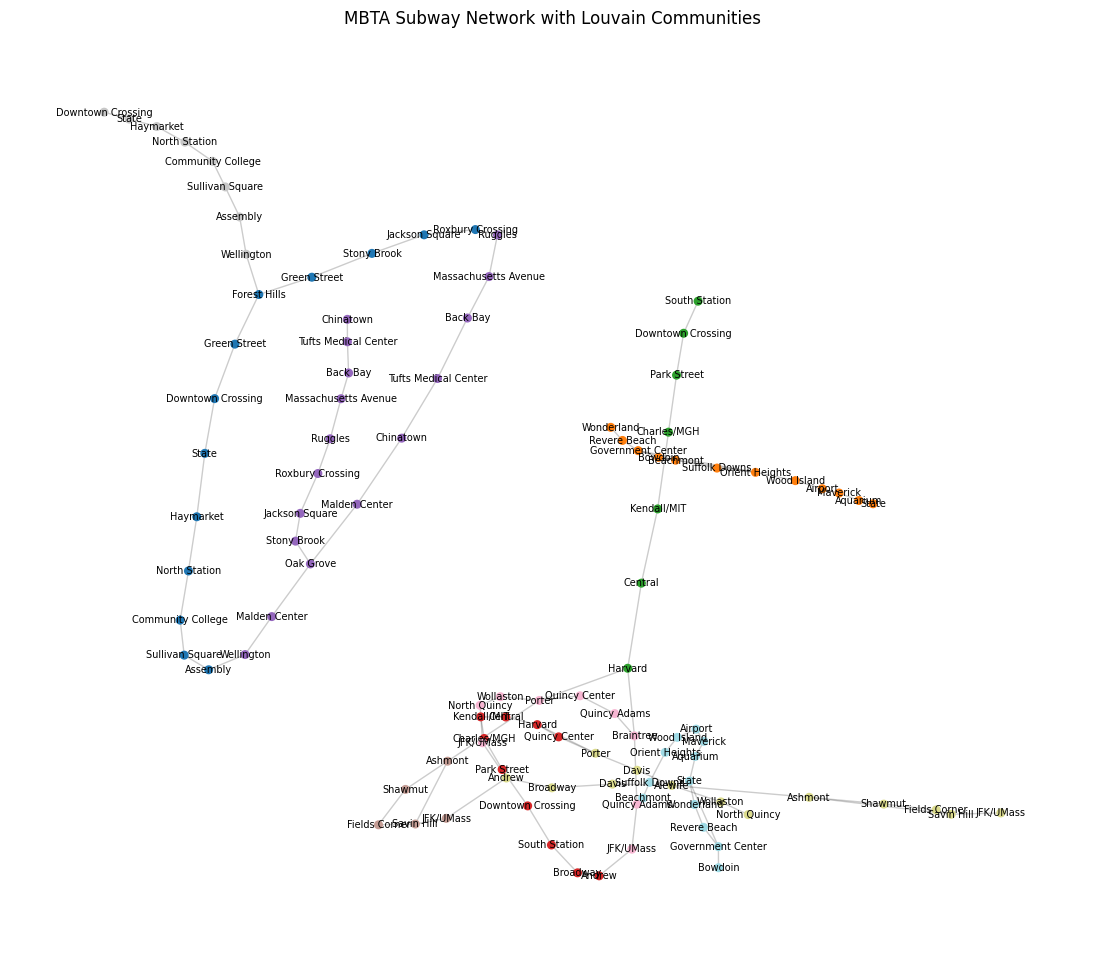

In [2]:
#####Code Only for Subway####
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
import zipfile

# === Step 1: Load GTFS data from ZIP file ===
zip_path = r"C:\Users\musta\Desktop\BU\pythonProject4\MBTA_GTFS (1).zip"

with zipfile.ZipFile(zip_path) as z:
    # Load required GTFS files
    with z.open("stops.txt") as stops_file, \
         z.open("stop_times.txt") as stop_times_file, \
         z.open("routes.txt") as routes_file, \
         z.open("trips.txt") as trips_file:
        
        stops_df = pd.read_csv(stops_file, dtype=str)
        stop_times_df = pd.read_csv(stop_times_file, dtype=str)
        routes_df = pd.read_csv(routes_file, dtype=str)
        trips_df = pd.read_csv(trips_file, dtype=str)

    # === Step 2: Filter only subway trips (route_type == 1) ===
    subway_routes = routes_df[routes_df["route_type"] == "1"]["route_id"]
    subway_trips = trips_df[trips_df["route_id"].isin(subway_routes)]["trip_id"]
    stop_times_df = stop_times_df[stop_times_df["trip_id"].isin(subway_trips)]

# === Step 3: Build edges from consecutive stops in each trip ===
edge_weights = defaultdict(int)

for trip_id, group in stop_times_df.groupby("trip_id"):
    group = group.sort_values("stop_sequence")
    stop_ids = group["stop_id"].tolist()

    for i in range(len(stop_ids) - 1):
        edge = tuple(sorted((stop_ids[i], stop_ids[i + 1])))
        edge_weights[edge] += 1

# === Step 4: Create the graph ===
G = nx.Graph()

# Add edges to the graph with weight (frequency of appearance)
for (stop1, stop2), weight in edge_weights.items():
    G.add_edge(stop1, stop2, weight=weight)

print(f"✅ Subway-only graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# === Step 5: Apply Louvain community detection ===
partition = community_louvain.best_partition(G, weight='weight')
modularity_score = community_louvain.modularity(partition, G, weight='weight')

print(f"✅ Louvain community detection complete.")
print(f"🧩 Modularity score: {modularity_score:.4f}")
print(f"🗂️ Detected {len(set(partition.values()))} communities.")

# === Step 6: Visualization with Stop Names ===
stop_names_dict = dict(zip(stops_df['stop_id'], stops_df['stop_name']))

plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, seed=42)

cmap = plt.get_cmap('tab20', max(partition.values()) + 1)
nx.draw_networkx_nodes(G, pos, node_size=30, cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Add stop name labels to make graph more interpretable
labels = {node: stop_names_dict.get(node, node) for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_color='black')

plt.title("MBTA Subway Network with Louvain Communities")
plt.axis("off")
plt.show()

In [3]:
from collections import Counter

# === Step 6: Analyze Communities ===
# 1. Community Sizes
community_sizes = Counter(partition.values())
print("Community Sizes:")
for community, size in community_sizes.items():
    print(f"Community {community}: {size} nodes")

# 2. High Degree Nodes in Communities
print("\nHigh Degree Nodes in Each Community:")
for community in set(partition.values()):
    # Get nodes in this community
    community_nodes = [node for node, comm in partition.items() if comm == community]
    
    # Create a subgraph for the community
    subgraph = G.subgraph(community_nodes)
    
    # Find nodes with highest degree
    degrees = subgraph.degree()
    high_degree_nodes = sorted(degrees, key=lambda x: x[1], reverse=True)[:5]  # Top 5 nodes
    print(f"Community {community}:")
    for node, degree in high_degree_nodes:
        stop_name = stops_df[stops_df['stop_id'] == node]['stop_name'].values[0] if len(stops_df[stops_df['stop_id'] == node]) > 0 else "Unknown"
        print(f"  Stop: {stop_name}, Degree: {degree}")

# 3. Community Composition (Stop Names)
print("\nCommunity Composition:")
for community in set(partition.values()):
    community_nodes = [node for node, comm in partition.items() if comm == community]
    stop_names = []
    for node in community_nodes:
        stop_name = stops_df[stops_df['stop_id'] == node]['stop_name'].values[0] if len(stops_df[stops_df['stop_id'] == node]) > 0 else "Unknown"
        stop_names.append(stop_name)
    print(f"Community {community}: {', '.join(stop_names[:5])} ...")  # Show first 5 stop names for brevity


Community Sizes:
Community 2: 22 nodes
Community 4: 8 nodes
Community 6: 8 nodes
Community 8: 12 nodes
Community 0: 12 nodes
Community 1: 9 nodes
Community 3: 12 nodes
Community 5: 11 nodes
Community 7: 7 nodes
Community 9: 5 nodes

High Degree Nodes in Each Community:
Community 0:
  Stop: Orient Heights, Degree: 4
  Stop: Government Center, Degree: 4
  Stop: Beachmont, Degree: 3
  Stop: Bowdoin, Degree: 3
  Stop: Airport, Degree: 2
Community 1:
  Stop: Quincy Adams, Degree: 2
  Stop: Wollaston, Degree: 2
  Stop: Quincy Center, Degree: 2
  Stop: Quincy Adams, Degree: 2
  Stop: Braintree, Degree: 2
Community 2:
  Stop: Community College, Degree: 2
  Stop: Tufts Medical Center, Degree: 2
  Stop: Massachusetts Avenue, Degree: 2
  Stop: Roxbury Crossing, Degree: 2
  Stop: Assembly, Degree: 2
Community 3:
  Stop: Porter, Degree: 3
  Stop: Harvard, Degree: 3
  Stop: Broadway, Degree: 2
  Stop: Charles/MGH, Degree: 2
  Stop: Kendall/MIT, Degree: 2
Community 4:
  Stop: Jackson Square, Degree: 

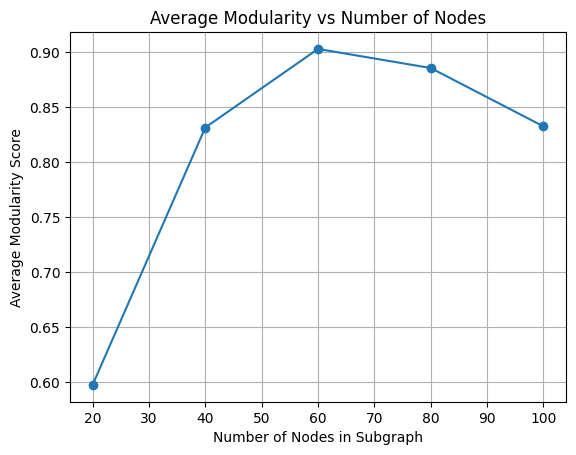


📊 Average Modularity Scores by Subgraph Size:
 Number of Nodes  Average Modularity
              20              0.5972
              40              0.8314
              60              0.9029
              80              0.8855
             100              0.8324


In [4]:
#####Modularity with different number of nodes ###

import random
import numpy as np
import matplotlib.pyplot as plt

node_counts = [20, 40, 60, 80, 100]
repeats = 5
avg_modularities = []

for n in node_counts:
    modularities = []
    
    for _ in range(repeats):
        sample_nodes = random.sample(list(G.nodes()), n)
        subgraph = G.subgraph(sample_nodes).copy()

        if subgraph.number_of_edges() > 0:
            partition = community_louvain.best_partition(subgraph, weight='weight')
            modularity = community_louvain.modularity(partition, subgraph, weight='weight')
            modularities.append(modularity)
    
    avg_modularity = np.mean(modularities)
    avg_modularities.append(avg_modularity)

# Plot the result
plt.plot(node_counts, avg_modularities, marker='o')
plt.title("Average Modularity vs Number of Nodes")
plt.xlabel("Number of Nodes in Subgraph")
plt.ylabel("Average Modularity Score")
plt.grid(True)
plt.show()


import pandas as pd

# Create DataFrame
modularity_df = pd.DataFrame({
    "Number of Nodes": node_counts,
    "Average Modularity": [round(m, 4) for m in avg_modularities]
})

# Display the table
print("\n📊 Average Modularity Scores by Subgraph Size:")
print(modularity_df.to_string(index=False))


   Number of Nodes  Time (sec)
0               20    0.005832
1               40    0.008251
2               60    0.035835
3               80    0.032536
4              100    0.028094


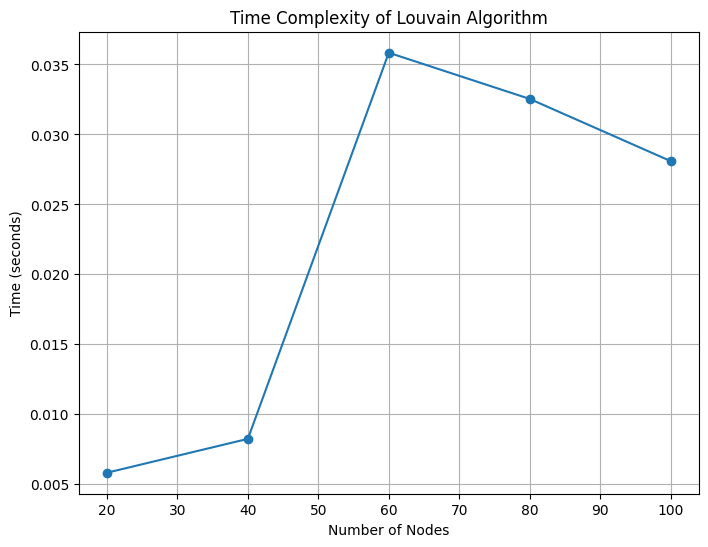

In [16]:
######time taken for Louvain algorithm on different subgraph sizes

import time
import matplotlib.pyplot as plt
import pandas as pd
import community as community_louvain
import networkx as nx

# Function to measure time taken for Louvain algorithm on different subgraph sizes
def measure_louvain_time_complexity(G, node_sizes):
    times = []
    
    for size in node_sizes:
        # Create subgraph with the first 'size' nodes
        sub_nodes = list(G.nodes())[:size]
        G_sub = G.subgraph(sub_nodes)
        
        # Run Louvain algorithm and measure time
        start_time = time.time()
        community_louvain.best_partition(G_sub, weight='weight')
        end_time = time.time()
        
        # Store the time taken for this size
        times.append(end_time - start_time)
    
    return times

# === Load your graph (you already have this part in your code) ===
# Assuming `G` is the full graph

# Define the node sizes (e.g., 20, 40, 60, 80, 100)
node_sizes = [20, 40, 60, 80, 100]

# Measure time taken for Louvain algorithm at different subgraph sizes
times = measure_louvain_time_complexity(G, node_sizes)

# Create a DataFrame for easy visualization and analysis
df_time_complexity = pd.DataFrame({
    'Number of Nodes': node_sizes,
    'Time (sec)': times
})

# Display the results in a table format
print(df_time_complexity)

# Plot the time complexity (Time vs. Number of Nodes)
plt.figure(figsize=(8, 6))
plt.plot(df_time_complexity['Number of Nodes'], df_time_complexity['Time (sec)'], marker='o')
plt.xlabel('Number of Nodes')
plt.ylabel('Time (seconds)')
plt.title('Time Complexity of Louvain Algorithm')
plt.grid(True)
plt.show()


📊 Louvain Analysis Results:
 Number of Nodes  Modularity  Time (sec)
              20      0.6250    0.000000
              40      0.7793    0.007246
              60      0.8693    0.011736
              80      0.8726    0.006819
             100      0.8423    0.011770


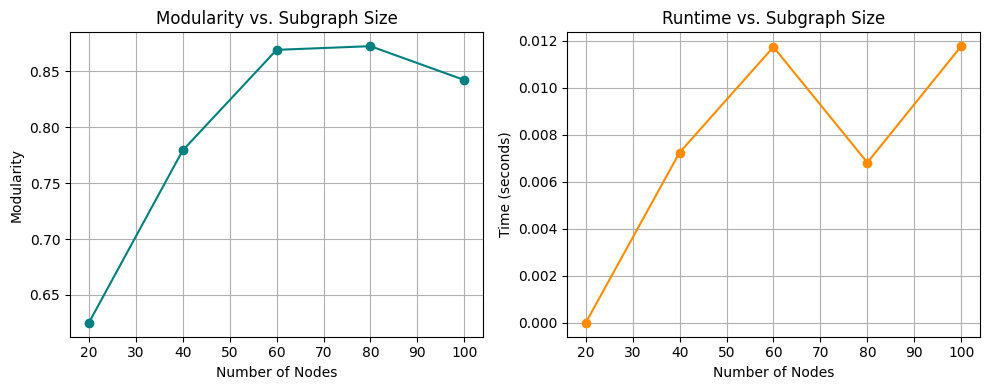

In [15]:
#Together Modularity and time 
import networkx as nx
import community as community_louvain
import pandas as pd
import time
import random
import matplotlib.pyplot as plt

# === Assumes you already have the full graph G created ===

subgraph_sizes = [20, 40, 60, 80, 100]
results = []

for size in subgraph_sizes:
    random.seed(42)  # for reproducibility
    sampled_nodes = random.sample(list(G.nodes()), size)
    subgraph = G.subgraph(sampled_nodes)

    start_time = time.time()
    partition = community_louvain.best_partition(subgraph, weight='weight')
    end_time = time.time()

    modularity = community_louvain.modularity(partition, subgraph, weight='weight')
    elapsed_time = end_time - start_time

    results.append({
        "Number of Nodes": size,
        "Modularity": round(modularity, 4),
        "Time (sec)": round(elapsed_time, 6)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results in tabular format
print("\n📊 Louvain Analysis Results:")
print(results_df.to_string(index=False))

# Optional: Plot results
plt.figure(figsize=(10, 4))

# Modularity Plot
plt.subplot(1, 2, 1)
plt.plot(results_df["Number of Nodes"], results_df["Modularity"], marker='o', color='teal')
plt.title("Modularity vs. Subgraph Size")
plt.xlabel("Number of Nodes")
plt.ylabel("Modularity")
plt.grid(True)

# Time Plot
plt.subplot(1, 2, 2)
plt.plot(results_df["Number of Nodes"], results_df["Time (sec)"], marker='o', color='darkorange')
plt.title("Runtime vs. Subgraph Size")
plt.xlabel("Number of Nodes")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [20]:
#Space complexity
import psutil
import os

# Function to get memory usage in MB
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 ** 2  # in MB

# Record memory usage before and after graph creation and Louvain
mem_before = get_memory_usage()

# Create the graph and apply Louvain as before
G = nx.Graph()
for (stop1, stop2), weight in edge_weights.items():
    G.add_edge(stop1, stop2, weight=weight)

mem_after_creation = get_memory_usage()

partition = community_louvain.best_partition(G, weight='weight')

mem_after_louvain = get_memory_usage()

# Print memory usage
print(f"Memory usage before graph creation: {mem_before:.2f} MB")
print(f"Memory usage after graph creation: {mem_after_creation:.2f} MB")
print(f"Memory usage after Louvain: {mem_after_louvain:.2f} MB")

Memory usage before graph creation: 88.46 MB
Memory usage after graph creation: 88.48 MB
Memory usage after Louvain: 88.57 MB


In [22]:
# Calculate the weight of edges between different partitions
edge_weights_between_partitions = 0
for (node1, node2, data) in G.edges(data=True):
    if partition[node1] != partition[node2]:
        edge_weights_between_partitions += data['weight']

print(f"Total edge weights between different partitions: {edge_weights_between_partitions}")


Total edge weights between different partitions: 8481


In [23]:
#Calculate the sum of edge weights for each partition
partition_weights = defaultdict(int)

for (node1, node2, data) in G.edges(data=True):
    if partition[node1] == partition[node2]:
        partition_weights[partition[node1]] += data['weight']

# Calculate the differences in weights between partitions
weight_differences = [abs(weight - partition_weights[community]) for community, weight in partition_weights.items()]
print(f"Node partitions weight differences: {weight_differences}")

Node partitions weight differences: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
